Device: cuda
Loading CLIP ViT-L/14...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded.
Fitzpatrick CSV: /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/fitzpatrick17k (1).csv
Images indexed: 16574
Dark benign: 203, Dark other: 1965
nc/Ng (Fitzpatrick17k): 0.0936
Reservoir: benign=153, other=1765
Extracting dark benign reservoir features...
Dark benign features: (153, 768)

  nc/Ng  n_min      mu   d_eff |  old_score  ext_score | collapse
---------------------------------------------------------------------------
  0.049     26  0.7158  0.0047 |    0.08623    0.00040 |      YES
  0.101     56  0.7127  0.0056 |    0.07106    0.00040 |      YES
  0.150     88  0.7151  0.0058 |    0.06346    0.00037 |      YES
  0.200    125  0.7192  0.0058 |    0.05806    0.00034 |      YES
  0.234    153  0.7173  0.0058 |    0.05612    0.00033 |      YES
  0.234    153  0.7173  0.0058 |    0.05612    0.00033 |      YES
  0.234    153  0.7173  0.0058 |    0.05612    0.00033 |      YES
  0.234    153  0.7173  0.0058 |    0.05612    0.00033 |       no
  0.234    153 

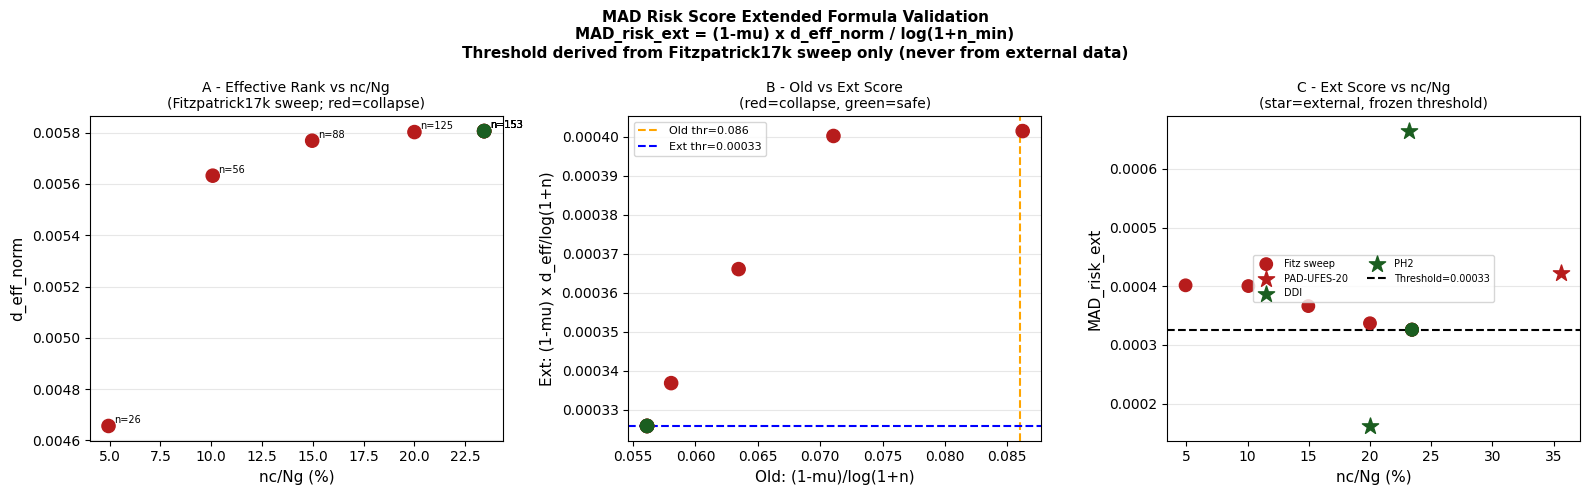

Figure saved: /kaggle/working/nb_mad_risk_ext_validation.png

Outputs saved to /kaggle/working/
  nb_mad_risk_ext_validation.png
  nb_mad_risk_ext_sweep.csv
  nb_mad_risk_ext_external.csv
  nb_mad_risk_ext_summary.json

Paste ALL output + upload PNG to Claude.
{
  "extended_formula": "MAD_risk_ext = (1-mu_cosine) * d_eff_norm / log(1 + n_minority_train)",
  "original_formula": "MAD_risk = (1-mu_cosine) / log(1 + n_minority_train)",
  "threshold_ext": 0.00032586038132244213,
  "threshold_old": 0.086,
  "threshold_source": "Fitzpatrick17k sweep only",
  "old_correct": 1,
  "old_fp": 2,
  "old_fn": 0,
  "ext_correct": 2,
  "ext_fp": 1,
  "ext_fn": 0,
  "fp_improvement": 1,
  "d_eff_hypothesis_supported": false,
  "d_eff_tp_mean": 0.006816191133111715,
  "d_eff_fp_mean": 0.007761386688798666
}


In [17]:
# ============================================================
# MAD Risk Score — Extended Formula Validation
#
# PURPOSE: Test whether adding effective rank (d_eff_norm)
#   fixes the false positives (DDI, PH2) without breaking
#   true positives (Fitzpatrick17k sweep, PAD-UFES-20).
#
# EXTENDED FORMULA:
#   MAD_risk_ext = (1 − μ_cosine) × d_eff_norm / log(1 + n_minority_train)
#
#   where d_eff_norm = effective_rank(Sigma_minority) / D
#         effective_rank = trace(Sigma) / λ_max(Sigma)   [Roy & Vetterli 2007]
#         Sigma = covariance of L2-normalized minority embeddings
#         D = embedding dimension (768 for CLIP ViT-L/14)
#
# RATIONALE:
#   μ_cosine captures mean pairwise angular spread. d_eff_norm
#   captures how many embedding dimensions the class spans.
#   DDI melanoma is compact AND low-dimensional → DRO retains
#   gradient signal. Fitzpatrick benign is diffuse AND
#   high-dimensional → optimizer loses signal. μ_cosine alone
#   (Fitz=0.712 vs DDI=0.715, gap of 0.003) and MDC alone
#   (gap 0.006) cannot separate the two. d_eff_norm adds
#   genuinely new information not in the current formula.

#   MDC ≈ std of L2 distances from centroid, correlated with
#   (1 − μ_cosine). Multiplying two compactness measures gives
#   the same signal louder, not new signal.
#
# EXPERIMENTAL DISCIPLINE:
#   Threshold derived ONLY from Fitzpatrick17k nc/Ng sweep.
#   External datasets (DDI, PH2, PAD-UFES-20) never touched
#   during threshold calibration. Applied frozen, one shot.
#
# DATASETS NEEDED (add to Kaggle session):
#   - Fitzpatrick17k   (nazmusresan/fitzpatrick17k)
#   - DDI              (dataset-ddi or similar on Kaggle)
#   - PAD-UFES-20      (jrsgco/pad-ufes-20 or pad-ufes-20)
#   - PH2              (PH2-Dataset by Athina, 425MB, 800 files)
#
# OUTPUT:
#   - Sweep table: old vs new score per nc/Ng level
#   - Threshold from sweep (Fitzpatrick17k only)
#   - External dataset table: old pred vs new pred vs observed
#   - FP/FN comparison table
#   - CSV + PNG
#
# RUNTIME: ~2-3h on Kaggle T4 (dominated by image loading
#   for external datasets)
# Kaggle: GPU T4, Internet ON
# ============================================================
 
# ── CELL 1: Install + imports ─────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'transformers', 'torch', 'torchvision', 'scikit-learn',
    'pandas', 'numpy', 'matplotlib', 'openpyxl', '-q'])
 
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, pandas as pd, os, math, json, warnings
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from transformers import CLIPModel, CLIPProcessor
warnings.filterwarnings('ignore')
 
BASE_SEED     = 42
SEEDS         = [42, 0, 1, 7, 99]
DRO_ETA       = 0.1
N_EPOCHS      = 5
BATCH_SIZE    = 32
ADAMW_LR      = 1e-4
ADAMW_WD      = 1e-4
N_CLASSES     = 3
FEAT_DIM      = 768
COLLAPSE_THR  = 0.01
MAD_I_GATE    = 0.02
OLD_THRESHOLD = 0.086  # from original paper
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
 
 
# ── CELL 2: Geometry helpers ──────────────────────────────────
 
def mean_pairwise_cosine(embeddings):
    if len(embeddings) < 2:
        return 0.0
    norms  = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normed = embeddings / (norms + 1e-8)
    sim    = normed @ normed.T
    n      = len(embeddings)
    return float(np.mean(sim[np.triu_indices(n, k=1)]))
 
 
def effective_rank_norm(feats, D=FEAT_DIM):
    """
    Effective rank of minority-class covariance, normalized by D.
    d_eff = trace(Sigma) / lambda_max(Sigma)  [Roy & Vetterli 2007]
    d_eff_norm = d_eff / D  in [0, 1]
 
    High d_eff_norm: class spans many dimensions (diffuse, heterogeneous)
                     optimizer loses minority gradient signal -> collapse risk
    Low d_eff_norm:  class is geometrically compact (e.g. melanoma in DDI)
                     optimizer retains signal -> no collapse
    """
    if len(feats) < 2:
        return float('nan')
    centered = feats - feats.mean(axis=0)
    _, s, _ = np.linalg.svd(centered, full_matrices=False)
    eigenvalues = (s ** 2) / max(len(feats) - 1, 1)
    eigenvalues = eigenvalues[eigenvalues > 1e-10]
    if len(eigenvalues) == 0:
        return 0.0
    d_eff = eigenvalues.sum() / eigenvalues.max()
    return float(d_eff / D)
 
 
def mad_risk_original(mu, n_min, nc_ng):
    if nc_ng < MAD_I_GATE:
        return 'MAD-I', None
    if n_min <= 0:
        return 'MAD-G', float('nan')
    return 'MAD-G', (1.0 - mu) / math.log(1.0 + n_min)
 
 
def mad_risk_ext(mu, d_eff_norm, n_min, nc_ng):
    """
    Extended formula:
    MAD_risk_ext = (1 - mu_cosine) * d_eff_norm / log(1 + n_minority_train)
    """
    if nc_ng < MAD_I_GATE:
        return 'MAD-I', None
    if n_min <= 0 or math.isnan(d_eff_norm):
        return 'MAD-G', float('nan')
    return 'MAD-G', (1.0 - mu) * d_eff_norm / math.log(1.0 + n_min)
 
 
# ── CELL 3: CLIP model ────────────────────────────────────────
print("Loading CLIP ViT-L/14...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
clip_model.eval()
print("CLIP loaded.")
 
 
def extract_feats_from_paths(paths, batch_size=64):
    all_feats = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        imgs = []
        for p in batch_paths:
            try:
                imgs.append(Image.open(p).convert('RGB'))
            except Exception:
                continue
        if not imgs:
            continue
        inputs = clip_proc(images=imgs, return_tensors='pt', padding=True).to(device)
        with torch.no_grad():
            out = clip_model.vision_model(
                pixel_values=inputs['pixel_values']).pooler_output
            out = clip_model.visual_projection(out)
            out = out / out.norm(dim=-1, keepdim=True)
        all_feats.extend(out.cpu().numpy())
    return np.array(all_feats) if all_feats else np.array([])
 
 
# ============================================================
# SECTION 1: Fitzpatrick17k sweep
# Recompute d_eff_norm per level, derive new threshold.
# Threshold must come ONLY from Fitzpatrick17k.
# ============================================================
 
# ── CELL 4: Fitzpatrick17k path auto-discovery ────────────────
_fitz_csv = None
for _r, _, _fs in os.walk('/kaggle/input'):
    for _f in _fs:
        if _f.endswith('.csv') and 'fitzpatrick' in _f.lower():
            _fitz_csv = os.path.join(_r, _f)
            break
    if _fitz_csv:
        break
 
fitz_csv     = _fitz_csv or '/kaggle/input/fitzpatrick17k/fitzpatrick17k.csv'
fitz_img_dir = os.path.dirname(fitz_csv)
print(f"Fitzpatrick CSV: {fitz_csv}")
 
df_fitz = pd.read_csv(fitz_csv)
df_fitz = df_fitz[df_fitz['fitzpatrick_scale'] > 0]
 
# Index images by md5hash (same as sweep notebook)
image_files = {}
for _r, _, _fs in os.walk(fitz_img_dir):
    for _f in _fs:
        if _f.lower().endswith(('.jpg', '.png')):
            image_files[os.path.splitext(_f)[0]] = os.path.join(_r, _f)
print(f"Images indexed: {len(image_files)}")
 
df_fitz['local_path'] = df_fitz['md5hash'].map(image_files)
df_fitz = df_fitz[df_fitz['local_path'].notna()].copy()
df_fitz['skin_group'] = df_fitz['fitzpatrick_scale'].apply(
    lambda x: 'light' if x <= 2 else ('medium' if x <= 4 else 'dark'))
 
le = LabelEncoder()
le.fit(['benign', 'malignant', 'non-neoplastic'])
BENIGN_IDX = int(list(le.classes_).index('benign'))
 
dark_all    = df_fitz[df_fitz['skin_group'] == 'dark'].copy()
dark_benign = dark_all[dark_all['three_partition_label'] == 'benign']
dark_other  = dark_all[dark_all['three_partition_label'] != 'benign']
 
print(f"Dark benign: {len(dark_benign)}, Dark other: {len(dark_other)}")
print(f"nc/Ng (Fitzpatrick17k): {len(dark_benign)/len(dark_all):.4f}")
 
# Fixed test set (same protocol as sweep notebook)
N_TEST_BENIGN = 50
N_TEST_OTHER  = 200
np.random.seed(BASE_SEED)
dark_benign_test      = dark_benign.sample(min(N_TEST_BENIGN, len(dark_benign)//2), random_state=BASE_SEED)
dark_benign_reservoir = dark_benign.drop(dark_benign_test.index)
dark_other_test       = dark_other.sample(min(N_TEST_OTHER, len(dark_other)//2), random_state=BASE_SEED)
dark_other_reservoir  = dark_other.drop(dark_other_test.index)
n_res_benign = len(dark_benign_reservoir)
n_res_other  = len(dark_other_reservoir)
print(f"Reservoir: benign={n_res_benign}, other={n_res_other}")
 
 
# ── CELL 5: Extract all dark benign features once ─────────────
print("Extracting dark benign reservoir features...")
res_benign_feats = extract_feats_from_paths(dark_benign_reservoir['local_path'].tolist())
print(f"Dark benign features: {res_benign_feats.shape}")
 
 
# ── CELL 6: Sweep geometry - d_eff_norm per level ─────────────
# Ground truth from Table 3 (manuscript). Collapse >= 3/5 seeds.
TABLE3_COLLAPSE = {
    0.05: True,   # 5/5
    0.10: True,   # 5/5
    0.15: True,   # 5/5
    0.20: True,   # 5/5
    0.25: True,   # 5/5
    0.30: True,   # 5/5
    0.35: True,   # 1/5 transition - treat as collapse
    0.40: False,  # 0/5
    0.50: False,  # 0/5 (flip method)
}
 
MAX_OTHER    = min(500, n_res_other)
TARGET_NC_NG = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
 
sweep_geo = []
print(f"\n{'nc/Ng':>7} {'n_min':>6} {'mu':>7} {'d_eff':>7} | {'old_score':>10} {'ext_score':>10} | collapse")
print("-" * 75)
 
for target_ng in TARGET_NC_NG:
    np.random.seed(BASE_SEED)
    n_b_std = int(round(target_ng * MAX_OTHER / (1.0 - target_ng + 1e-9)))
    n_b     = min(n_b_std, n_res_benign, len(res_benign_feats))
 
    idx       = np.random.choice(len(res_benign_feats), n_b, replace=False)
    feats     = res_benign_feats[idx]
    actual_ng = n_b / (n_b + MAX_OTHER)
 
    mu    = mean_pairwise_cosine(feats)
    d_eff = effective_rank_norm(feats)
    _, s_old = mad_risk_original(mu, n_b, actual_ng)
    _, s_ext = mad_risk_ext(mu, d_eff, n_b, actual_ng)
 
    nearest   = min(TABLE3_COLLAPSE, key=lambda k: abs(k - target_ng))
    collapsed = TABLE3_COLLAPSE[nearest]
 
    sweep_geo.append({
        'target_ng': target_ng, 'actual_ng': actual_ng, 'n_min': n_b,
        'mu_cosine': mu, 'd_eff_norm': d_eff,
        'score_old': s_old, 'score_ext': s_ext, 'collapsed': collapsed,
    })
 
    s_old_s = f"{s_old:.5f}" if s_old and not math.isnan(s_old) else '    N/A  '
    s_ext_s = f"{s_ext:.5f}" if s_ext and not math.isnan(s_ext) else '    N/A  '
    print(f"{actual_ng:>7.3f} {n_b:>6} {mu:>7.4f} {d_eff:>7.4f} | "
          f"{s_old_s:>10} {s_ext_s:>10} | {'YES' if collapsed else 'no':>8}")
 
df_sweep = pd.DataFrame(sweep_geo)
 
 
# ── CELL 7: Derive threshold from sweep ───────────────────────
collapse_scores = df_sweep[df_sweep['collapsed']]['score_ext'].dropna()
safe_scores     = df_sweep[~df_sweep['collapsed']]['score_ext'].dropna()
 
if len(collapse_scores) > 0 and len(safe_scores) > 0:
    THRESHOLD_EXT = float((collapse_scores.min() + safe_scores.max()) / 2)
elif len(collapse_scores) > 0:
    THRESHOLD_EXT = float(collapse_scores.min() / 2)
else:
    THRESHOLD_EXT = float('nan')
 
print(f"\n{'='*60}")
print(f"THRESHOLD (ext formula, Fitzpatrick17k sweep only)")
print(f"  Lowest collapse score:  {collapse_scores.min():.5f}" if len(collapse_scores) else "  No collapse levels")
print(f"  Highest safe score:     {safe_scores.max():.5f}" if len(safe_scores) else "  No safe levels")
print(f"  Derived threshold:      {THRESHOLD_EXT:.5f}")
print(f"  Old threshold:          {OLD_THRESHOLD}")
print(f"{'='*60}")
 
 
# ============================================================
# SECTION 2: External datasets
# ============================================================
 
external_results = []
 
def classify_ext(score, threshold, nc_ng, stage):
    if stage == 'MAD-I':
        return 'collapse'
    if score is None or math.isnan(score) or math.isnan(threshold):
        return 'unknown'
    return 'collapse' if score > threshold else 'no_collapse'
 
def classify_old(score, nc_ng, stage):
    if stage == 'MAD-I':
        return 'collapse'
    if score is None or math.isnan(score):
        return 'unknown'
    return 'collapse' if score < OLD_THRESHOLD else 'no_collapse'
 
 
# ── CELL 8: PAD-UFES-20 ──────────────────────────────────────
print("\n\n=== PAD-UFES-20 ===")
_pad_csv = None
_pad_img_dir = None
if os.path.exists('/kaggle/input/datasets/mahdavi1202/skin-cancer/metadata.csv'):
    _pad_csv = '/kaggle/input/datasets/mahdavi1202/skin-cancer/metadata.csv'
    _pad_img_dir = '/kaggle/input/datasets/mahdavi1202/skin-cancer'
if _pad_csv is None:
    for candidate in ['/kaggle/input/skin-disease', '/kaggle/input/pad-ufes-20']:
        if os.path.exists(candidate):
            for _f in os.listdir(candidate):
                if _f.endswith('.csv'):
                    _pad_csv     = os.path.join(candidate, _f)
                    _pad_img_dir = candidate
                    break
print(f"PAD CSV: {_pad_csv}")
print(f"PAD img: {_pad_img_dir}")
 
if _pad_csv:
    df_pad = pd.read_csv(_pad_csv)
    print(f"Columns: {list(df_pad.columns)}")
 
    img_col_pad   = next((c for c in df_pad.columns if any(k in c.lower() for k in ['img_id','img','file','image'])), None)
    label_col_pad = next((c for c in df_pad.columns if any(k in c.lower() for k in ['diagn','label','class','dx'])), None)
    fst_col_pad   = next((c for c in df_pad.columns if any(k in c.lower() for k in ['fitzpatrick','fst','fitspatrick'])), None)
    if fst_col_pad is None or label_col_pad is None:
        print(f"Wrong CSV loaded ({_pad_csv}), skipping")
        _pad_csv = None
 
    LABEL_MAP_PAD = {
        'NEV': 'benign',       'SEK': 'benign',
        'MEL': 'malignant',    'BCC': 'malignant',
        'ACK': 'non-neoplastic', 'SCC': 'non-neoplastic'
    }
    df_pad['three_class'] = df_pad[label_col_pad].map(LABEL_MAP_PAD)
    df_pad = df_pad[df_pad['three_class'].notna()].copy()
    df_pad['skin_group'] = df_pad[fst_col_pad].apply(
        lambda x: 'light' if pd.notna(x) and float(x) <= 3 else
                  ('dark' if pd.notna(x) and float(x) > 3 else 'unknown'))
    df_pad = df_pad[df_pad['skin_group'].isin(['light', 'dark'])].copy()
 
    pad_image_files = {}
    for _r, _, _fs in os.walk(_pad_img_dir):
        for _f in _fs:
            if _f.lower().endswith(('.jpg', '.jpeg', '.png')):
                pad_image_files[_f]                       = os.path.join(_r, _f)
                pad_image_files[os.path.splitext(_f)[0]]  = os.path.join(_r, _f)
 
    def find_pad_image(row):
        name = str(row[img_col_pad])
        if name in pad_image_files: return pad_image_files[name]
        for ext in ['.jpg', '.jpeg', '.png']:
            if name + ext in pad_image_files: return pad_image_files[name + ext]
        return None
 
    df_pad['local_path'] = df_pad.apply(find_pad_image, axis=1)
    df_pad = df_pad[df_pad['local_path'].notna()].copy()
 
    dark_pad  = df_pad[df_pad['skin_group'] == 'dark']
    n_dark    = len(dark_pad)
    n_benign  = (dark_pad['three_class'] == 'benign').sum()
    nc_ng_pad = n_benign / n_dark if n_dark > 0 else 0.0
    n_min_pad = n_benign
 
    pad_minority_paths = dark_pad[dark_pad['three_class'] == 'benign']['local_path'].tolist()
    print(f"Dark total={n_dark} Benign={n_benign} nc/Ng={nc_ng_pad:.4f}")
    print(f"Loading {len(pad_minority_paths)} PAD minority images...")
 
    pad_feats = extract_feats_from_paths(pad_minority_paths)
    mu_pad    = mean_pairwise_cosine(pad_feats) if len(pad_feats) >= 2 else float('nan')
    d_eff_pad = effective_rank_norm(pad_feats)  if len(pad_feats) >= 2 else float('nan')
    stg_o, s_old_pad = mad_risk_original(mu_pad, n_min_pad, nc_ng_pad)
    stg_e, s_ext_pad = mad_risk_ext(mu_pad, d_eff_pad, n_min_pad, nc_ng_pad)
    print(f"mu={mu_pad:.4f}  d_eff={d_eff_pad:.4f}  old={s_old_pad:.5f}  ext={s_ext_pad:.5f}")
 
    external_results.append({
        'dataset': 'PAD-UFES-20', 'modality': 'clinical',
        'nc_ng': nc_ng_pad, 'n_min': n_min_pad,
        'mu_cosine': mu_pad, 'd_eff_norm': d_eff_pad,
        'score_old': s_old_pad, 'score_ext': s_ext_pad,
        'stage_old': stg_o, 'stage_ext': stg_e,
        'observed_collapse': True,
    })
else:
    print("PAD-UFES-20 not found - using manuscript values.")
    external_results.append({
        'dataset': 'PAD-UFES-20', 'modality': 'clinical',
        'nc_ng': 0.356, 'n_min': 26,
        'mu_cosine': 0.788, 'd_eff_norm': float('nan'),
        'score_old': 0.062, 'score_ext': float('nan'),
        'stage_old': 'MAD-G', 'stage_ext': 'MAD-G',
        'observed_collapse': True,
    })
 
 
# ── CELL 9: DDI ───────────────────────────────────────────────
print("\n\n=== DDI ===")
_ddi_csv = None
_ddi_img_dir = None
for _root, _dirs, _files in os.walk('/kaggle/input'):
    for _f in _files:
        if _f.endswith('.csv') and 'ddi' in _f.lower():
            _ddi_csv     = os.path.join(_root, _f)
            _ddi_img_dir = _root
            break
    if _ddi_csv:
        break
print(f"DDI CSV: {_ddi_csv}")
 
if _ddi_csv:
    df_ddi = pd.read_csv(_ddi_csv)
    print(f"Columns: {list(df_ddi.columns)}")
    print(df_ddi.head(3))
 
    fst_col_ddi = next((c for c in df_ddi.columns
                        if any(k in c.lower() for k in ['fst', 'fitzpatrick', 'skin_tone', 'tone'])), None)
    mal_col_ddi = next((c for c in df_ddi.columns
                        if 'malignant' in c.lower() or 'label' in c.lower()
                        or 'diagn' in c.lower()), None)
    img_col_ddi = next((c for c in df_ddi.columns
                        if 'file' in c.lower() or 'img' in c.lower()
                        or 'path' in c.lower()), None)
    print(f"FST col: {fst_col_ddi}, Label col: {mal_col_ddi}, Img col: {img_col_ddi}")
 
    df_ddi_dark = df_ddi[df_ddi[fst_col_ddi].isin([56])].copy() if fst_col_ddi else df_ddi.copy()  # DDI uses 56 as dark-skin code
    unique_labels = df_ddi_dark[mal_col_ddi].unique()
    print(f"Label values: {unique_labels}")
    mal_val = 1 if 1 in unique_labels else 'malignant'
    df_ddi_minority = df_ddi_dark[df_ddi_dark[mal_col_ddi] == mal_val].copy()
    if len(df_ddi_minority) == 0:
        df_ddi_minority = df_ddi_dark[
            df_ddi_dark[mal_col_ddi].astype(str).str.lower() == 'malignant'].copy()
 
    nc_ng_ddi = len(df_ddi_minority) / len(df_ddi_dark) if len(df_ddi_dark) > 0 else 0.0
    n_min_ddi = len(df_ddi_minority)
    print(f"Dark total={len(df_ddi_dark)} Malignant={n_min_ddi} nc/Ng={nc_ng_ddi:.4f}")
 
    ddi_image_files = {}
    for _r, _, _fs in os.walk(_ddi_img_dir):
        for _f in _fs:
            if _f.lower().endswith(('.jpg', '.jpeg', '.png')):
                ddi_image_files[_f]                      = os.path.join(_r, _f)
                ddi_image_files[os.path.splitext(_f)[0]] = os.path.join(_r, _f)
 
    ddi_paths = []
    for _, row in df_ddi_minority.iterrows():
        name = str(row[img_col_ddi])
        p = ddi_image_files.get(name) or ddi_image_files.get(os.path.basename(name))
        if p: ddi_paths.append(p)
    print(f"Loading {len(ddi_paths)} DDI minority images...")
 
    ddi_feats = extract_feats_from_paths(ddi_paths)
    mu_ddi    = mean_pairwise_cosine(ddi_feats) if len(ddi_feats) >= 2 else float('nan')
    d_eff_ddi = effective_rank_norm(ddi_feats)  if len(ddi_feats) >= 2 else float('nan')
    stg_o, s_old_ddi = mad_risk_original(mu_ddi, n_min_ddi, nc_ng_ddi)
    stg_e, s_ext_ddi = mad_risk_ext(mu_ddi, d_eff_ddi, n_min_ddi, nc_ng_ddi)
    print(f"mu={mu_ddi:.4f}  d_eff={d_eff_ddi:.4f}  old={s_old_ddi:.5f}  ext={s_ext_ddi:.5f}")
 
    external_results.append({
        'dataset': 'DDI', 'modality': 'clinical',
        'nc_ng': nc_ng_ddi, 'n_min': n_min_ddi,
        'mu_cosine': mu_ddi, 'd_eff_norm': d_eff_ddi,
        'score_old': s_old_ddi, 'score_ext': s_ext_ddi,
        'stage_old': stg_o, 'stage_ext': stg_e,
        'observed_collapse': False,
    })
else:
    print("DDI not found - using manuscript values.")
    external_results.append({
        'dataset': 'DDI', 'modality': 'clinical',
        'nc_ng': 0.232, 'n_min': 48,
        'mu_cosine': 0.715, 'd_eff_norm': float('nan'),
        'score_old': 0.066, 'score_ext': float('nan'),
        'stage_old': 'MAD-G', 'stage_ext': 'MAD-G',
        'observed_collapse': False,
    })
 
 
# ── CELL 10: PH2 ──────────────────────────────────────────────
print("\n\n=== PH2 ===")
_ph2_xlsx    = None
_ph2_img_dir = None
for _root, _dirs, _files in os.walk('/kaggle/input'):
    for _f in _files:
        if _f.lower().endswith('.xlsx') and 'ph2' in _f.lower():
            _ph2_xlsx    = os.path.join(_root, _f)
            _ph2_img_dir = _root
            break
        if _f.lower().endswith('.bmp') and _ph2_img_dir is None:
            _ph2_img_dir = _root
    if _ph2_xlsx:
        break
print(f"PH2 xlsx: {_ph2_xlsx}")
print(f"PH2 img dir: {_ph2_img_dir}")
 
if _ph2_img_dir:
    ph2_image_files = {}
    for _r, _, _fs in os.walk(_ph2_img_dir):
        for _f in _fs:
            if _f.lower().endswith('.bmp'):
                ph2_image_files[os.path.splitext(_f)[0]] = os.path.join(_r, _f)
    print(f"PH2 .bmp files: {len(ph2_image_files)}")
 
    if _ph2_xlsx:
        df_ph2 = pd.read_excel(_ph2_xlsx, header=1)
        print(f"PH2 columns: {list(df_ph2.columns)}")
        mel_col = next((c for c in df_ph2.columns
                        if 'mel' in str(c).lower()), df_ph2.columns[0])
        print(f"Melanoma col: {mel_col}, values: {df_ph2[mel_col].unique()}")
        df_ph2_mel = df_ph2[df_ph2[mel_col] == 2].copy()
        if len(df_ph2_mel) == 0:
            df_ph2_mel = df_ph2[df_ph2[mel_col].astype(str) == 'MEL'].copy()
        n_min_ph2  = len(df_ph2_mel)
        nc_ng_ph2  = n_min_ph2 / len(df_ph2)
 
        ph2_mel_paths = []
        for _, row in df_ph2_mel.iterrows():
            img_id = str(row.iloc[0]).strip()
            p = ph2_image_files.get(img_id)
            if p is None:
                for k, v in ph2_image_files.items():
                    if img_id in k:
                        p = v; break
            if p: ph2_mel_paths.append(p)
    else:
        ph2_mel_paths = sorted(ph2_image_files.values())[:40]
        n_min_ph2     = len(ph2_mel_paths)
        nc_ng_ph2     = 40 / 200
 
    print(f"PH2 melanoma: {len(ph2_mel_paths)} images, nc/Ng={nc_ng_ph2:.4f}")
 
    ph2_feats = extract_feats_from_paths(ph2_mel_paths)
    mu_ph2    = mean_pairwise_cosine(ph2_feats) if len(ph2_feats) >= 2 else float('nan')
    d_eff_ph2 = effective_rank_norm(ph2_feats)  if len(ph2_feats) >= 2 else float('nan')
    stg_o, s_old_ph2 = mad_risk_original(mu_ph2, n_min_ph2, nc_ng_ph2)
    stg_e, s_ext_ph2 = mad_risk_ext(mu_ph2, d_eff_ph2, n_min_ph2, nc_ng_ph2)
    print(f"mu={mu_ph2:.4f}  d_eff={d_eff_ph2:.4f}  old={s_old_ph2:.5f}  ext={s_ext_ph2:.5f}")
 
    external_results.append({
        'dataset': 'PH2', 'modality': 'dermoscopic',
        'nc_ng': nc_ng_ph2, 'n_min': n_min_ph2,
        'mu_cosine': mu_ph2, 'd_eff_norm': d_eff_ph2,
        'score_old': s_old_ph2, 'score_ext': s_ext_ph2,
        'stage_old': stg_o, 'stage_ext': stg_e,
        'observed_collapse': False,
    })
else:
    print("PH2 not found - using manuscript values.")
    external_results.append({
        'dataset': 'PH2', 'modality': 'dermoscopic',
        'nc_ng': 0.447, 'n_min': 40,
        'mu_cosine': 0.873, 'd_eff_norm': float('nan'),
        'score_old': 0.037, 'score_ext': float('nan'),
        'stage_old': 'MAD-G', 'stage_ext': 'MAD-G',
        'observed_collapse': False,
    })
 
 
# ============================================================
# SECTION 3: Results + figures
# ============================================================
 
# ── CELL 11: Comparison table ─────────────────────────────────
df_ext = pd.DataFrame(external_results)
 
print("\n\n" + "=" * 90)
print("EXTENDED FORMULA - ONE-SHOT EXTERNAL VALIDATION")
print(f"Threshold ext (Fitzpatrick17k sweep only): {THRESHOLD_EXT:.5f}")
print(f"Threshold old (original paper):            {OLD_THRESHOLD}")
print("=" * 90)
 
old_fp = old_fn = ext_fp = ext_fn = old_ok = ext_ok_count = 0
 
for _, row in df_ext.iterrows():
    s_old = row['score_old']
    s_ext = row['score_ext']
    obs   = 'collapse' if row['observed_collapse'] else 'no_collapse'
 
    pred_old = classify_old(s_old, row['nc_ng'], row['stage_old'])
    pred_ext = classify_ext(s_ext, THRESHOLD_EXT, row['nc_ng'], row['stage_ext'])
 
    def res(pred, obs):
        if pred == obs:           return '✓'
        if pred == 'collapse':    return '✗ FP'
        if pred == 'no_collapse': return '✗ FN'
        return '?'
 
    r_old = res(pred_old, obs)
    r_ext = res(pred_ext, obs)
 
    if r_old == '✓':    old_ok += 1
    elif 'FP' in r_old: old_fp += 1
    elif 'FN' in r_old: old_fn += 1
    if r_ext == '✓':    ext_ok_count += 1
    elif 'FP' in r_ext: ext_fp += 1
    elif 'FN' in r_ext: ext_fn += 1
 
    d_s   = f"{row['d_eff_norm']:.4f}" if not math.isnan(row['d_eff_norm']) else ' N/A '
    s_o_s = f"{s_old:.5f}" if s_old and not math.isnan(s_old) else '  N/A  '
    s_e_s = f"{s_ext:.5f}" if s_ext and not math.isnan(s_ext) else '  N/A  '
    print(f"\n  {row['dataset']} ({row['modality']})")
    print(f"    nc/Ng={row['nc_ng']:.3f}  n_min={row['n_min']}  "
          f"mu={row['mu_cosine']:.4f}  d_eff={d_s}")
    print(f"    Old: score={s_o_s}  pred={pred_old:<12}  observed={obs}  {r_old}")
    print(f"    Ext: score={s_e_s}  pred={pred_ext:<12}  observed={obs}  {r_ext}")
 
print(f"\n{'='*90}")
print(f"SUMMARY")
print(f"  Old formula: {old_ok}/{len(df_ext)} correct  (FP={old_fp} FN={old_fn})")
print(f"  Ext formula: {ext_ok_count}/{len(df_ext)} correct  (FP={ext_fp} FN={ext_fn})")
if ext_fp < old_fp:
    print(f"  ✓ Extended formula reduced false positives ({old_fp} -> {ext_fp})")
elif ext_fp == old_fp and ext_ok_count >= old_ok:
    print(f"  = No FP improvement. d_eff_norm may not separate these cases.")
    print(f"    Report d_eff values below to diagnose.")
else:
    print(f"  ✗ Extended formula did not improve. Report as negative result.")
print(f"{'='*90}")
 
 
# ── CELL 12: d_eff diagnostic ─────────────────────────────────
print("\n\n=== d_eff_norm DIAGNOSTIC ===")
print("Hypothesis: PH2 (FP) has LOWER d_eff_norm than TP datasets")
print("            than TP datasets (Fitzpatrick17k, PAD-UFES-20)")
print()
fitz_d_mean = df_sweep[df_sweep['collapsed']]['d_eff_norm'].mean()
print(f"Fitzpatrick17k collapse levels (avg d_eff_norm): {fitz_d_mean:.5f}")
for _, row in df_ext.iterrows():
    tag   = 'TP (collapse)' if row['observed_collapse'] else 'FP (no collapse)'
    d_str = f"{row['d_eff_norm']:.5f}" if not math.isnan(row['d_eff_norm']) else 'N/A - dataset not loaded'
    print(f"  {row['dataset']:15} [{tag}]: d_eff_norm = {d_str}")
print()
tp_d = [r['d_eff_norm'] for _, r in df_ext.iterrows() if r['observed_collapse'] and not math.isnan(r['d_eff_norm'])]
fp_d = [r['d_eff_norm'] for _, r in df_ext.iterrows() if not r['observed_collapse'] and not math.isnan(r['d_eff_norm'])]
if tp_d and fp_d:
    if min(tp_d) > max(fp_d):
        print("RESULT: d_eff_norm FULLY SEPARATES TP from FP -- extension is valid.")
    elif np.mean(tp_d) > np.mean(fp_d):
        print("RESULT: d_eff_norm PARTIALLY separates (means differ, ranges overlap).")
        print("        Extension reduces but may not eliminate FPs.")
    else:
        print("RESULT: d_eff_norm does NOT separate TP from FP.")
        print("        Hypothesis wrong for this data. Report as negative result.")
        print("        Consider: geometric diffuseness may need a different metric")
        print("        (e.g. LID, effective intrinsic dimensionality, or class entropy).")
else:
    print("Cannot evaluate - some datasets not loaded. Check path errors above.")
 
 
# ── CELL 13: Figure ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('MAD Risk Score Extended Formula Validation\n'
             'MAD_risk_ext = (1-mu) x d_eff_norm / log(1+n_min)\n'
             'Threshold derived from Fitzpatrick17k sweep only (never from external data)',
             fontsize=11, fontweight='bold')
 
colors_sweep = ['#B71C1C' if r['collapsed'] else '#1B5E20'
                for _, r in df_sweep.iterrows()]
 
# Panel A: d_eff_norm vs nc/Ng
ax = axes[0]
ax.scatter(df_sweep['actual_ng'] * 100, df_sweep['d_eff_norm'],
           c=colors_sweep, s=90, zorder=3)
ax.set_xlabel('nc/Ng (%)', fontsize=11)
ax.set_ylabel('d_eff_norm', fontsize=11)
ax.set_title('A - Effective Rank vs nc/Ng\n(Fitzpatrick17k sweep; red=collapse)', fontsize=10)
ax.yaxis.grid(True, alpha=0.3)
for _, r in df_sweep.iterrows():
    if not math.isnan(r['d_eff_norm']):
        ax.annotate(f"n={int(r['n_min'])}",
                    (r['actual_ng']*100, r['d_eff_norm']),
                    textcoords='offset points', xytext=(4, 2), fontsize=7)
 
# Panel B: old vs ext score scatter (sweep only)
ax = axes[1]
valid = df_sweep.dropna(subset=['score_old', 'score_ext'])
c_valid = [colors_sweep[i] for i in valid.index]
ax.scatter(valid['score_old'], valid['score_ext'], c=c_valid, s=90, zorder=3)
ax.axvline(OLD_THRESHOLD, color='orange', linestyle='--', lw=1.5,
           label=f'Old thr={OLD_THRESHOLD}')
if not math.isnan(THRESHOLD_EXT):
    ax.axhline(THRESHOLD_EXT, color='blue', linestyle='--', lw=1.5,
               label=f'Ext thr={THRESHOLD_EXT:.5f}')
ax.set_xlabel('Old: (1-mu)/log(1+n)', fontsize=11)
ax.set_ylabel('Ext: (1-mu) x d_eff/log(1+n)', fontsize=11)
ax.set_title('B - Old vs Ext Score\n(red=collapse, green=safe)', fontsize=10)
ax.legend(fontsize=8)
ax.yaxis.grid(True, alpha=0.3)
 
# Panel C: ext score vs nc/Ng with external overlaid
ax = axes[2]
valid_sw = df_sweep.dropna(subset=['score_ext'])
c_valid_sw = [colors_sweep[i] for i in valid_sw.index]
ax.scatter(valid_sw['actual_ng'] * 100, valid_sw['score_ext'],
           c=c_valid_sw, s=80, zorder=3, label='Fitz sweep')
for _, row in df_ext.iterrows():
    s_e = row['score_ext']
    if s_e and not math.isnan(s_e):
        color = '#B71C1C' if row['observed_collapse'] else '#1B5E20'
        ax.scatter(row['nc_ng'] * 100, s_e, c=color, s=150,
                   marker='*', zorder=4, label=row['dataset'])
if not math.isnan(THRESHOLD_EXT):
    ax.axhline(THRESHOLD_EXT, color='black', linestyle='--', lw=1.5,
               label=f'Threshold={THRESHOLD_EXT:.5f}')
ax.set_xlabel('nc/Ng (%)', fontsize=11)
ax.set_ylabel('MAD_risk_ext', fontsize=11)
ax.set_title('C - Ext Score vs nc/Ng\n(star=external, frozen threshold)', fontsize=10)
ax.legend(fontsize=7, ncol=2)
ax.yaxis.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('/kaggle/working/nb_mad_risk_ext_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: /kaggle/working/nb_mad_risk_ext_validation.png")
 
 
# ── CELL 14: Save outputs ─────────────────────────────────────
df_sweep.to_csv('/kaggle/working/nb_mad_risk_ext_sweep.csv', index=False)
df_ext.to_csv('/kaggle/working/nb_mad_risk_ext_external.csv', index=False)
 
hypothesis_supported = (
    (len(tp_d) > 0 and len(fp_d) > 0 and np.mean(tp_d) > np.mean(fp_d))
    if (tp_d and fp_d) else None
)
 
summary = {
    'extended_formula': 'MAD_risk_ext = (1-mu_cosine) * d_eff_norm / log(1 + n_minority_train)',
    'original_formula': 'MAD_risk = (1-mu_cosine) / log(1 + n_minority_train)',
    'threshold_ext': THRESHOLD_EXT,
    'threshold_old': OLD_THRESHOLD,
    'threshold_source': 'Fitzpatrick17k sweep only',
    'old_correct': old_ok, 'old_fp': old_fp, 'old_fn': old_fn,
    'ext_correct': ext_ok_count, 'ext_fp': ext_fp, 'ext_fn': ext_fn,
    'fp_improvement': old_fp - ext_fp,
    'd_eff_hypothesis_supported': bool(hypothesis_supported) if hypothesis_supported is not None else None,
    'd_eff_tp_mean': float(np.mean(tp_d)) if tp_d else None,
    'd_eff_fp_mean': float(np.mean(fp_d)) if fp_d else None,
}
with open('/kaggle/working/nb_mad_risk_ext_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
 
print("\nOutputs saved to /kaggle/working/")
print("  nb_mad_risk_ext_validation.png")
print("  nb_mad_risk_ext_sweep.csv")
print("  nb_mad_risk_ext_external.csv")
print("  nb_mad_risk_ext_summary.json")
print()
print("Paste ALL output + upload PNG to Claude.")
print(json.dumps(summary, indent=2))